# Tutorial

In [1]:
import sys
import os
from pathlib import Path
import json
import math
import matplotlib.pyplot as plt

# %ls
%cd ../

import predict
import load_data
import plot_prediction

%cd ../

/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu


I0000 00:00:1789554813.882496  780577 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789554813.882880  780577 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789554813.916687  780577 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789554814.894300  780577 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

/home/s2561233/Documents/lss/ridges/ridges_toolkit


In [2]:
PARAMETER_ORDER = [
    'bary_Mc',
    'bary_nu',
    'H0',
    'Omega_b',
    'Omega_m',
    'ns',
    'sigma8',
    'w0',
]

Firt of all let's create two datasets: one with the training and validating simulations and one

In [3]:
%run emu/build_dataset.py

Building dataset: 100%|██████████| 2500/2500 [00:07<00:00, 327.26it/s]


Let's now train the emulator. 
Note: this saves the models, so there's no need to re-run it unless you want to change the dataset.

In [4]:
%run emu/train.py

/home/s2561233/miniforge3/envs/ridges-toolkit/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1789554823.228643  780577 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


TRAINING PAIR: (0, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,756 (143.58 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,756 (143.58 KB)

 Trainable params: 36,756 (143.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6905 - val_loss: 0.6628
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6397 - val_loss: 0.6080
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5750 - val_loss: 0.5354
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4901 - val_loss: 0.4429
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3891 - val_loss: 0.3466
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2951 - val_loss: 0.2625
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2207 - val_loss: 0.1991
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1667 - val_loss: 0.1541
Epoch 9/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1308 - val_loss: 0.1262
Epoch 10/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1086 - val_loss: 0.1099
Epoch 11/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0960 - val_loss: 0.1002
Epoch 12/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0884 - val_lo

Once the emulator is trained, we can make some predictions. Here we're using some of the CosmoGRID simulations to make the prediction (these have been saved separately when running ``build_dataset.py`` and not been used in the training).

In [5]:
# get radial bins, mean and stdev from metadata
with open('emu/data/metadata.json', 'r') as f:
    metadata = json.load(f)

sep_bin_center = metadata['sep_bin_center']

# choose two simulations indices to plot against prediction
idx1 = 0
idx2 = 47

/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu/plot_prediction.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()
/tmp/ipykernel_780577/1405959449.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


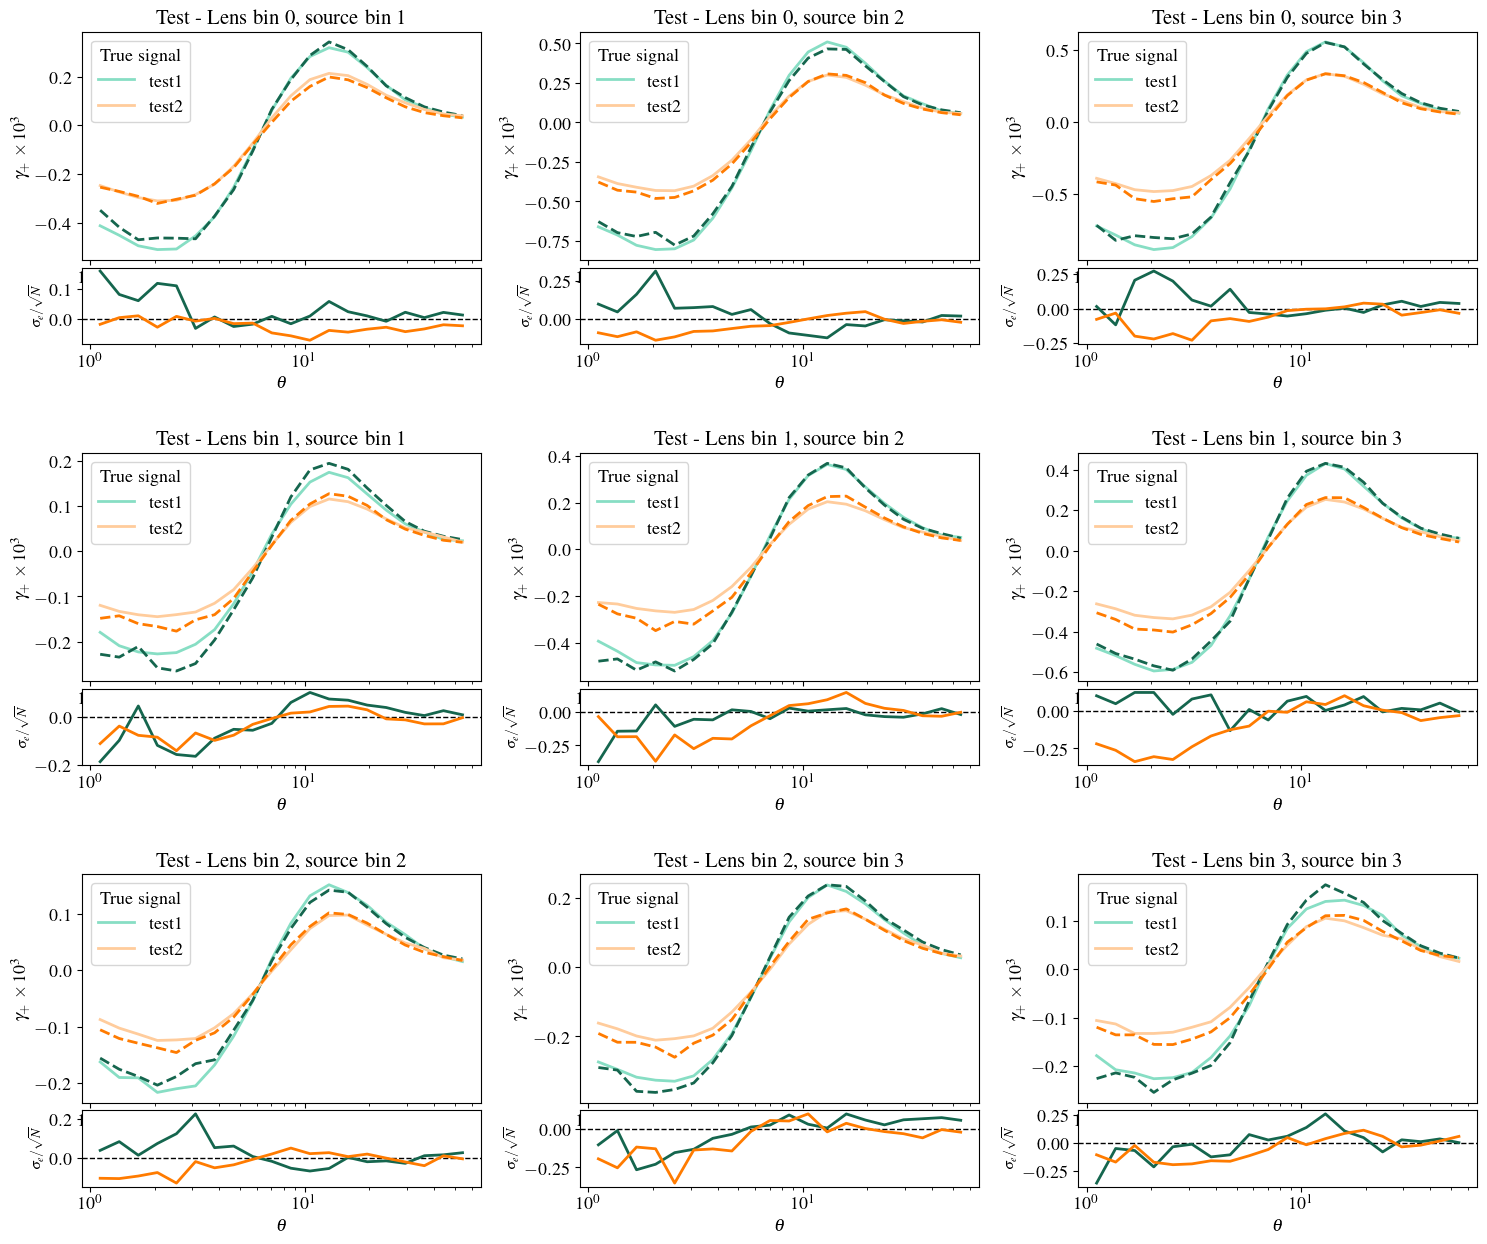

In [6]:
# big plot with multiple subplots, each one having a different bin pair (lens, source)
all_pairs = metadata["bin_pairs"]
ncols = 3
nrows = math.ceil(len(all_pairs) / ncols)
fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
outer_grid = fig.add_gridspec(nrows, ncols, hspace=0.35, wspace=0.25)

for panel_idx, (l, s) in enumerate(all_pairs):
    row = panel_idx // ncols
    col = panel_idx % ncols
    inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax0 = fig.add_subplot(inner_grid[0])
    ax1 = fig.add_subplot(inner_grid[1], sharex=ax0)

    model_path = 'emu/models/lens' + str(l) + '_source' + str(s) + '.keras'
    X_test, Y_test, shape_noise = load_data.load_dataset(l, s)

    # create dictionary with values of X_test
    params_dict = {par: X_test[:, i] for i, par in enumerate(PARAMETER_ORDER)}
    prediction = predict.make_prediction(params_dict, l, s, model_path)

    plot_prediction.plot_prediction_shapenoise(
        xarr=sep_bin_center,
        predicted_signal=prediction,
        true_signal=Y_test,
        shape_noise=shape_noise,
        l=l,
        s=s,
        idx1=idx1,
        idx2=idx2,
        xlabel=r'$\theta$',
        ylabel=r'$\gamma_+\, \times10^3$',
        legend=['test1', 'test2'],
        title=f'Test - Lens bin {l}, source bin {s}',
        ax0=ax0,
        ax1=ax1,
        save=False,
        savename='all_bins.pdf'
    )

# hide any unused panels if the grid is larger than the number of bin pairs
for panel_idx in range(len(all_pairs), nrows * ncols):
    row = panel_idx // ncols
    col = panel_idx % ncols
    fig.add_subplot(outer_grid[row, col]).axis('off')

fig.tight_layout()
plt.show()

In [7]:
print('Cosmological parameters of the two selected simulations:')
name_list = ['bary_Mc', 'bary_nu', 'H0', 'Ob', 'Om', 'ns', 's8', 'w0']
# create dictionary with names as in name_list and X_test[0,:] as values
dict = {name: X_test[idx1, i] for i, name in enumerate(name_list)}
print(f'Simulation {idx1}: {dict}')
dict = {name: X_test[idx2, i] for i, name in enumerate(name_list)}
print(f'Simulation {idx2}: {dict}')

Cosmological parameters of the two selected simulations:
Simulation 0: {'bary_Mc': np.float64(6180386354657.502), 'bary_nu': np.float64(1.6171875), 'H0': np.float64(64.87890625), 'Ob': np.float64(0.03134765625), 'Om': np.float64(0.34609375), 'ns': np.float64(1.033671875), 's8': np.float64(0.694921875), 'w0': np.float64(-0.661841796875)}
Simulation 47: {'bary_Mc': np.float64(2736880651783.1226), 'bary_nu': np.float64(-0.1787109375), 'H0': np.float64(75.5883789062), 'Ob': np.float64(0.051774902344), 'Om': np.float64(0.26357421875), 'ns': np.float64(0.984892578125), 's8': np.float64(0.621923828125), 'w0': np.float64(-0.979695068359)}


### Tests on training -- loss function

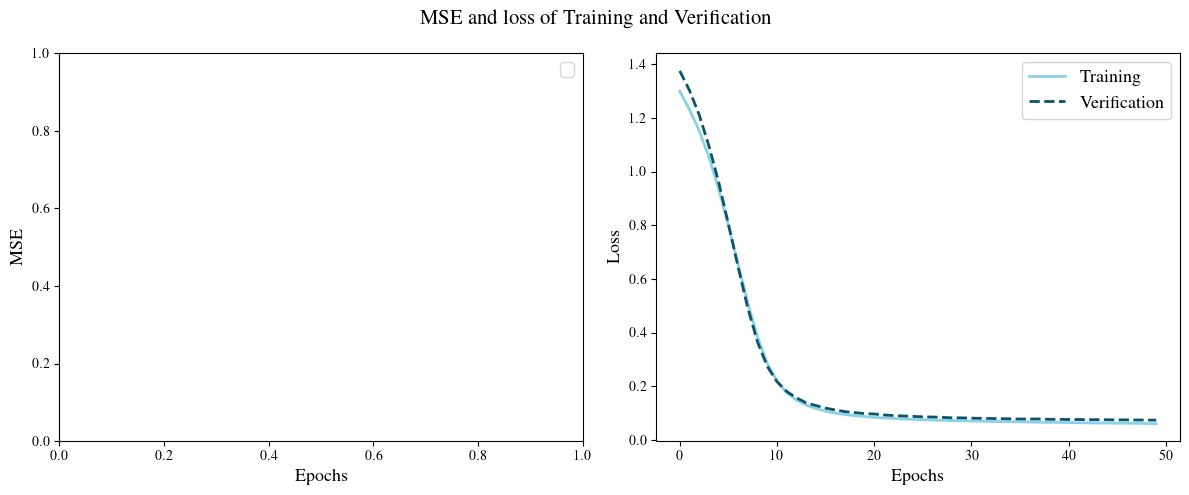

In [8]:
import pickle  

# Loading the history object
with open('emu/models/traing_history0_source1.pkl', 'rb') as file:
    loaded_history = pickle.load(file)

# mean square error
# mse_training = loaded_history['mse']
# mse_verify = loaded_history['val_mse']
# loss 
training_loss = loaded_history['loss']
validation_loss = loaded_history['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle('MSE and loss of Training and Verification', fontsize=15)

# ax[0].plot(mse_training, color='#8AD2E8', linewidth=2)
# ax[0].plot(mse_verify, linestyle='dashed', color="#0C536B", linewidth=2)
ax[0].set_ylabel('MSE', fontsize=13)
ax[0].set_xlabel('Epochs', fontsize=13)
ax[0].legend(['Training', 'Verification'], loc='upper right', fontsize=13)

ax[1].plot(training_loss, color='#8AD2E8', linewidth=2)
ax[1].plot(validation_loss, linestyle='dashed', color="#0C536B", linewidth=2)
ax[1].set_ylabel('Loss', fontsize=13)
ax[1].set_xlabel('Epochs', fontsize=13)
ax[1].legend(['Training', 'Verification'], loc='upper right', fontsize=13)

plt.tight_layout()